In [958]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

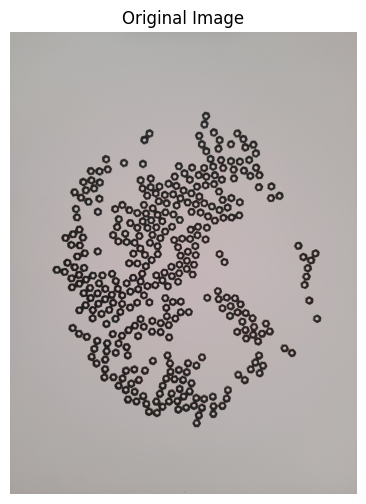

In [959]:
image=cv2.imread(r"D:\EDrivebackup\brocamp\DataScienceProjects\JIYAMARYJOSEPH\JIYAMARYJOSEPH\dataset\CountingChallenge\ScrewAndBolt_20240713\20240713_194630.jpg")
if image is None:
    raise FileNotFoundError("Image not loaded. Check the path or file format.")

original = image.copy()

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')
plt.show()

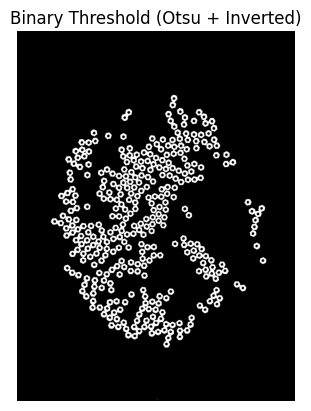

In [969]:

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray = clahe.apply(gray)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(binary, cmap='gray')
plt.title("Binary Threshold (Otsu + Inverted)")
plt.axis('off')
plt.show()


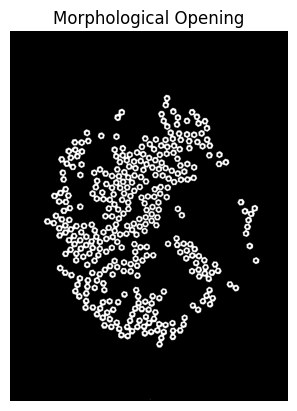

In [961]:
# Morphological Opening to reduce small noise
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
plt.imshow(opening, cmap='gray')
plt.title("Morphological Opening")
plt.axis('off')
plt.show()


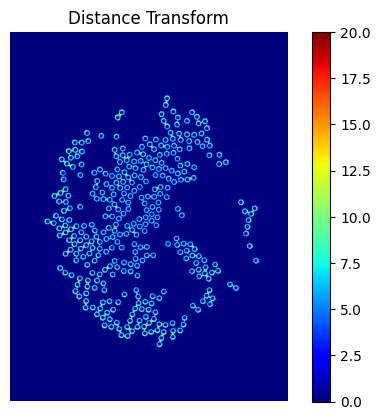

In [962]:
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
plt.imshow(dist, cmap='jet')
plt.title("Distance Transform")
plt.axis('off')
plt.colorbar()
plt.show()


In [963]:
noise_std = np.std(gray)
print(noise_std)

factor = (
    0.2 if noise_std>30 else
    0.1 if noise_std > 21 else
    0.05 if noise_std > 20 else
    0.3
       
   
)

_, sure_fg = cv2.threshold(dist, factor * dist.max(), 255, 0)
print(factor)

39.07489599632008
0.2


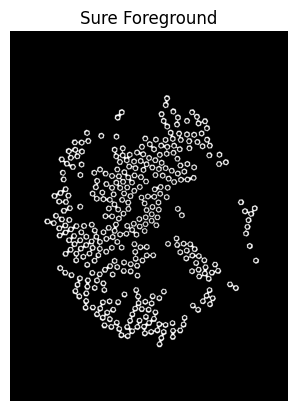

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [964]:

sure_fg = np.uint8(sure_fg)
plt.imshow(sure_fg, cmap='gray')
plt.title("Sure Foreground")
plt.axis('off')
plt.show()
print(sure_fg)


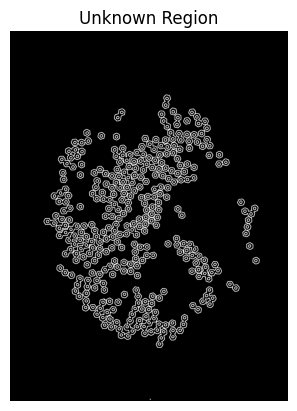

In [965]:
sure_bg = cv2.dilate(opening, kernel, iterations=3)
unknown = cv2.subtract(sure_bg, sure_fg)
plt.imshow(unknown, cmap='gray')
plt.title("Unknown Region")
plt.axis('off')
plt.show()


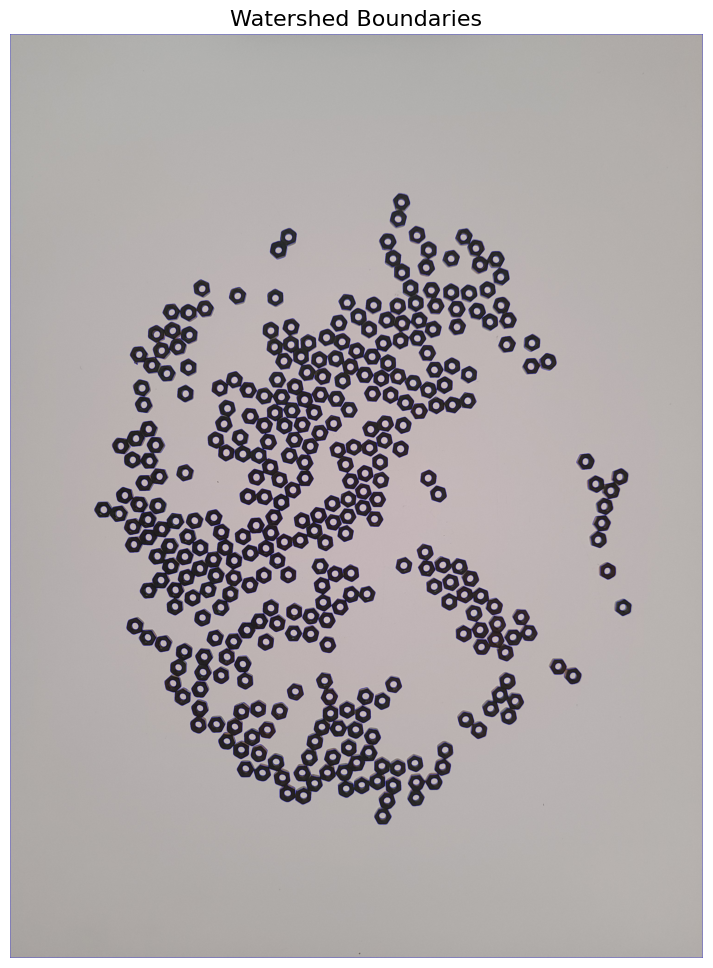

In [966]:
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
image_copy = image.copy()
markers = cv2.watershed(image_copy, markers)
image_copy[markers == -1] = [255, 0, 0] 
plt.figure(figsize=(16, 12))  
plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))
plt.title("Watershed Boundaries", fontsize=16)  
plt.axis('off')
plt.show()



In [967]:
object_count = 0
output = image.copy()

for label in np.unique(markers):
    if label <= 1:
        continue
    mask = np.uint8(markers == label)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        area = cv2.contourArea(cnt)
        # min_area = 0.001 * image.shape[0] * image.shape[1] 
        if area > 300:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 1)
            object_count += 1


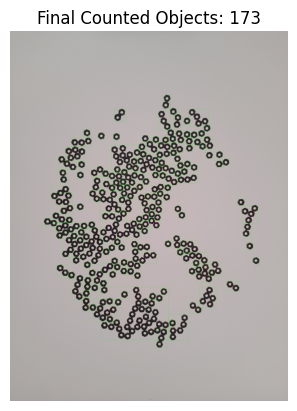

In [968]:
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f"Final Counted Objects: {object_count}")
plt.axis('off')
plt.show()
